<a href="https://colab.research.google.com/github/AnnSenina/Other/blob/main/NLP_%D0%B8%D1%82%D0%BE%D0%B3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.getcwd()

'/home/anna/Загрузки/Паломники РНФ_2'

In [ ]:
os.chdir('/home/anna/Загрузки/Паломники РНФ_2')

In [ ]:
from nltk.corpus import stopwords
mystop_words = stopwords.words('russian')

In [ ]:
def plot_all_metric_heatmaps_grid(metric_results, authors, ncols=3, figsize=(18, 24)):
    """
    Рисует тепловые карты для всех метрик в одной сетке подграфиков.
    """
    metric_names = list(metric_results.keys())
    n_metrics = len(metric_names)
    nrows = (n_metrics + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()

    for i, (metric_name, (res, auth_list)) in enumerate(metric_results.items()):
        if i >= len(axes):
            break
        df = pd.DataFrame(res, columns=['chapter'] + auth_list)
        df.set_index('chapter', inplace=True)
        sns.heatmap(df, annot=True, fmt='.3f', cmap='RdBu_r',
                    cbar_kws={'label': metric_name}, ax=axes[i])
        axes[i].set_title(metric_name, fontsize=10)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Глава')
        axes[i].tick_params(axis='x', rotation=90)

    # Скрыть лишние подграфики
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

Using device: cuda:0


[nltk_data] Error loading stopwords: <urlopen error [Errno 110]
[nltk_data]     Connection timed out>


Загружено глав: 10, авторов: 5
Вычисление cosine_freq...
Вычисление cosine_tfidf...
Вычисление jaccard...
Вычисление word_ngram...
Вычисление char_ngram...
Вычисление function_words_cosine...
Вычисление char_ngram_cosine_3...
Вычисление char_ngram_cosine_4...
Вычисление collocation_llr...
Вычисление collocation_tscore...
Вычисление delta_p...
TTR глав: {1: {'TTR': 0.6069836552748885, 'Entropy': 8.973848868508162, 'YuleK': 0.004660774646798946}, 2: {'TTR': 0.4827534267208917, 'Entropy': 10.422810364179165, 'YuleK': 0.003969569057272271}, 3: {'TTR': 0.511926192619262, 'Entropy': 10.054079357867456, 'YuleK': 0.004170511560607006}, 4: {'TTR': 0.4346826126954922, 'Entropy': 10.36422274142433, 'YuleK': 0.0055905801946395}, 5: {'TTR': 0.43899500946480813, 'Entropy': 10.010027874191497, 'YuleK': 0.004384838408253847}, 6: {'TTR': 0.4435604177026355, 'Entropy': 10.426016168235037, 'YuleK': 0.00447309810957684}, 7: {'TTR': 0.49741131351869605, 'Entropy': 10.207820370106434, 'YuleK': 0.00390620389

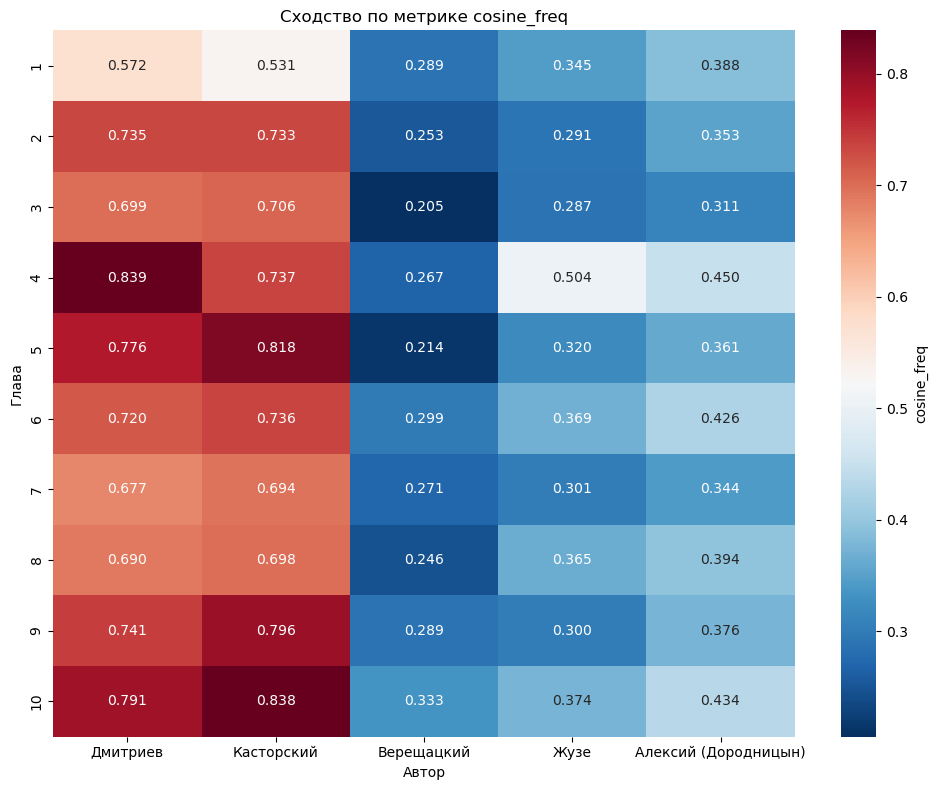

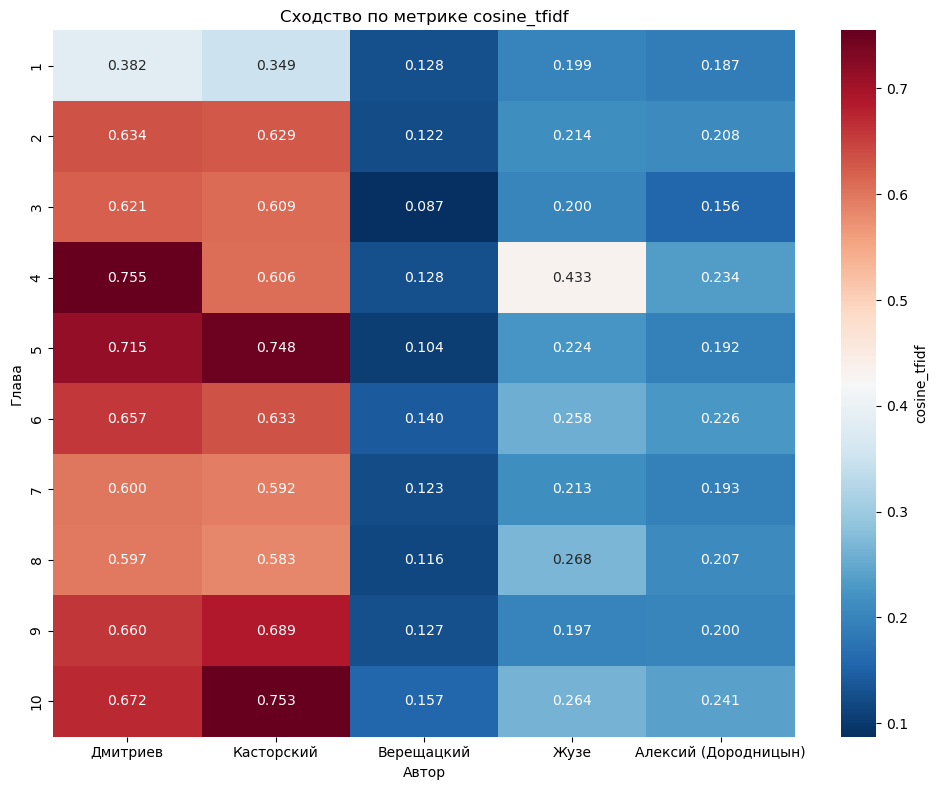

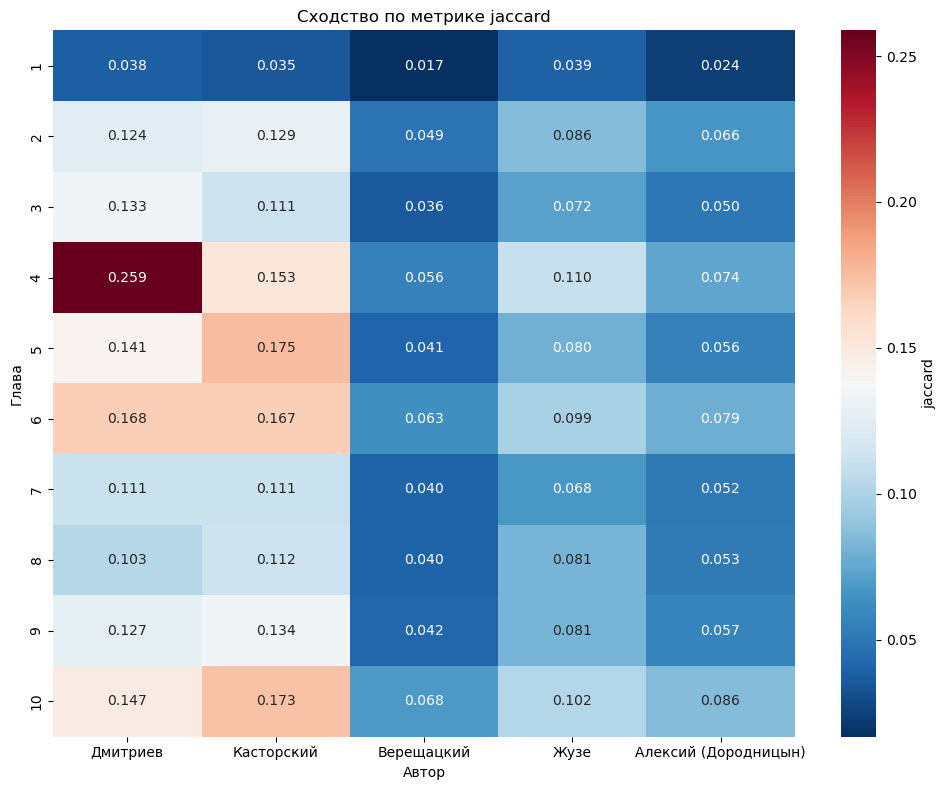

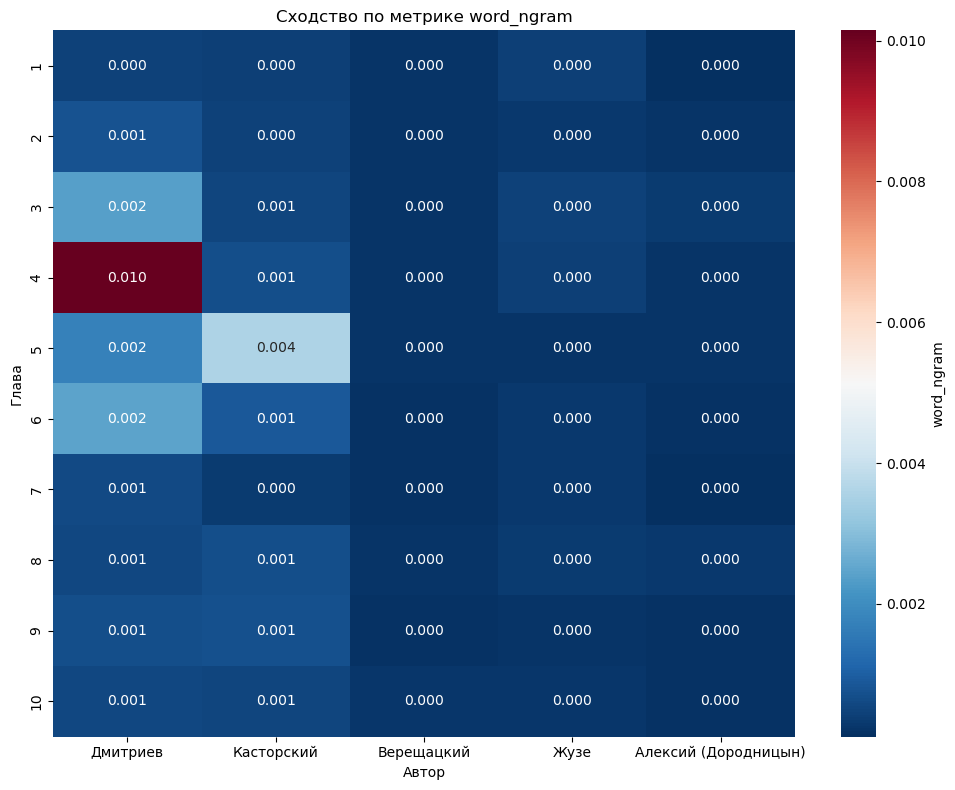

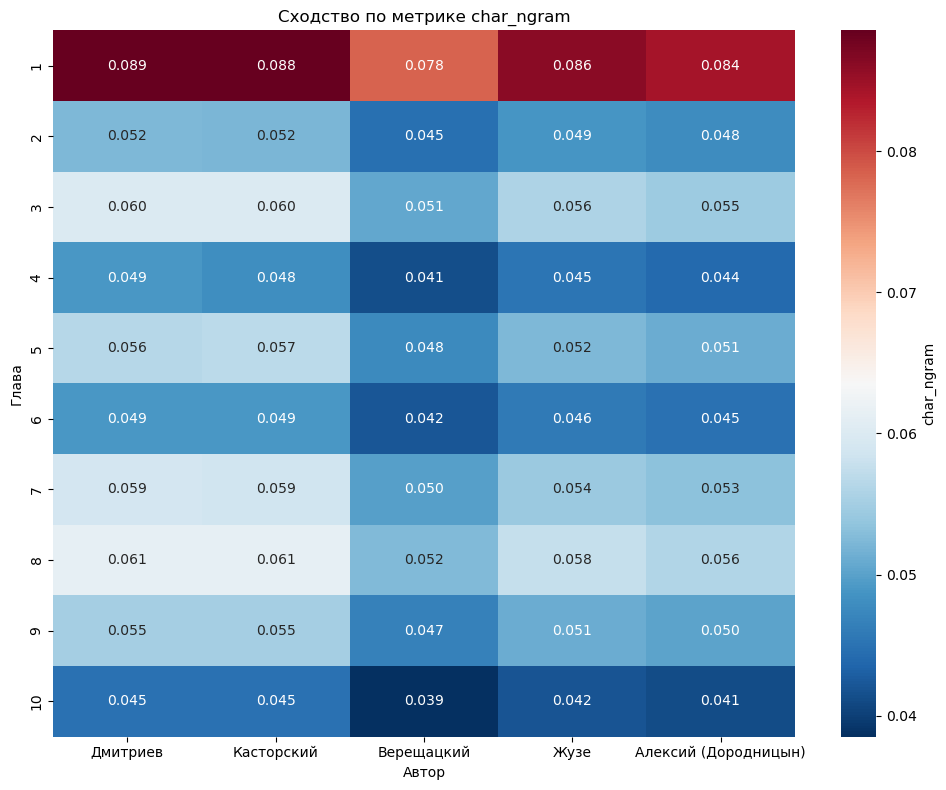

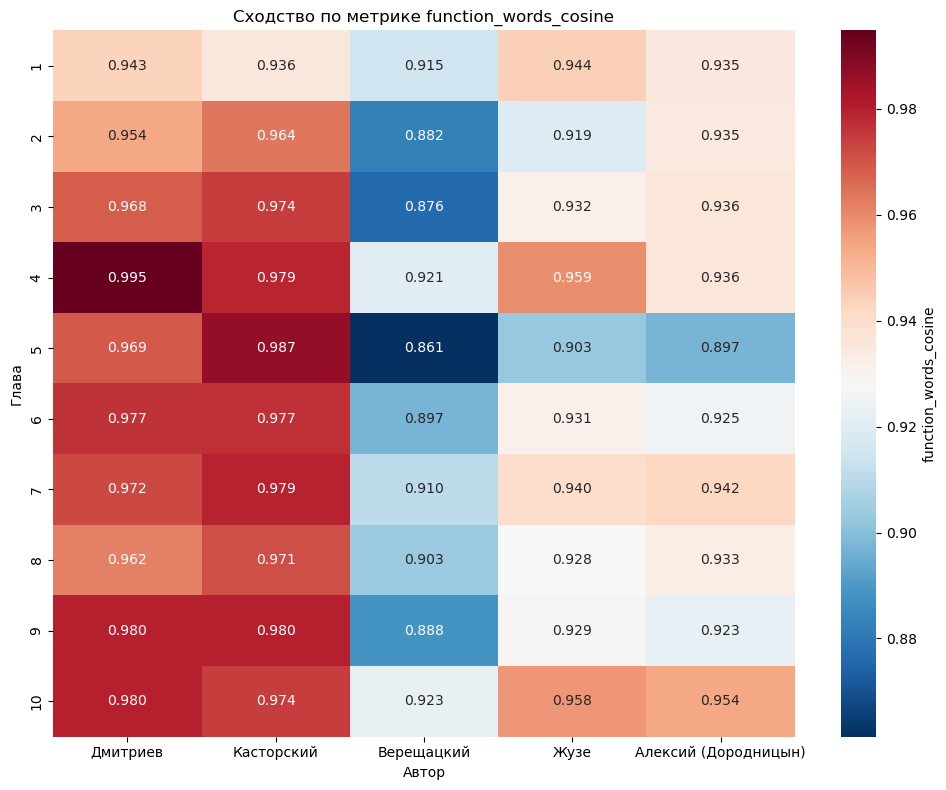

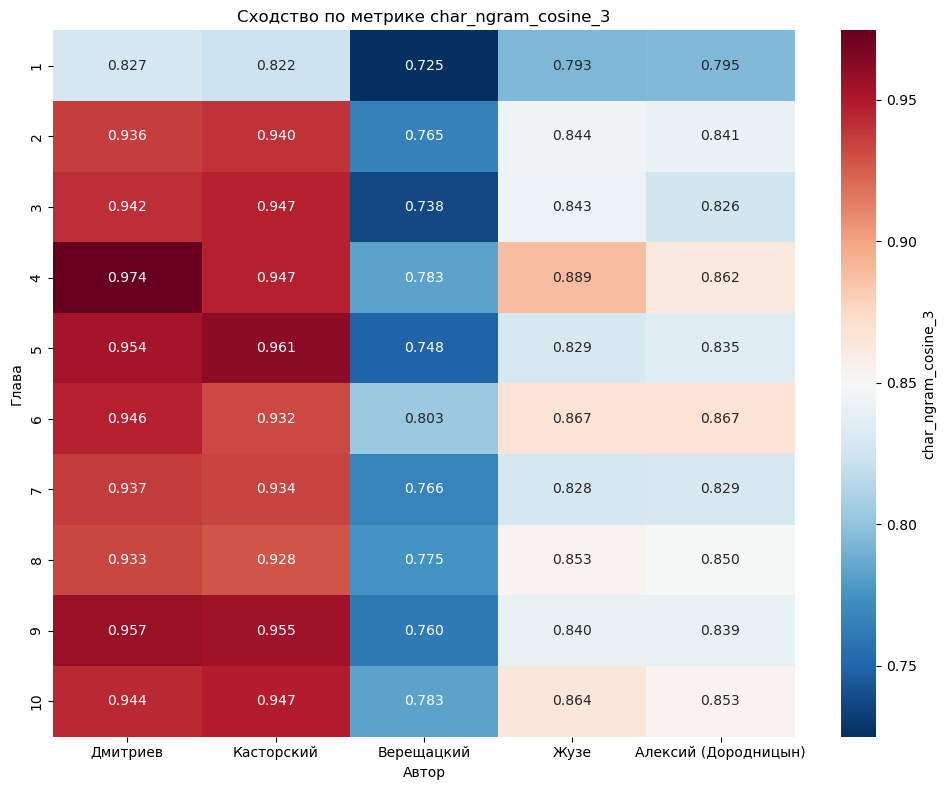

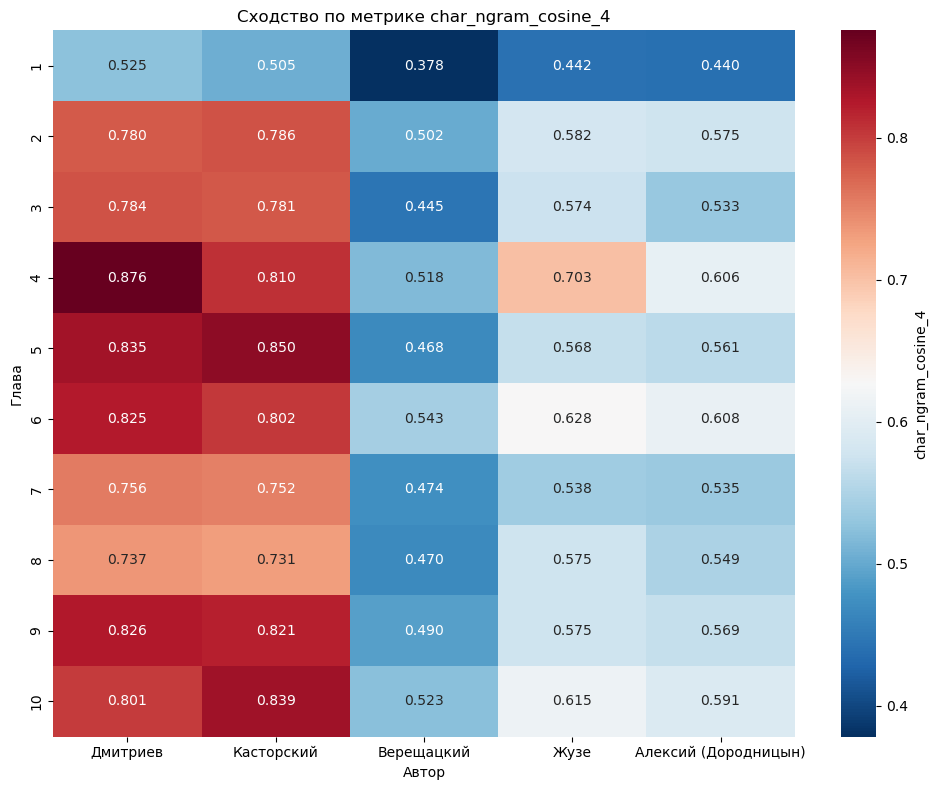

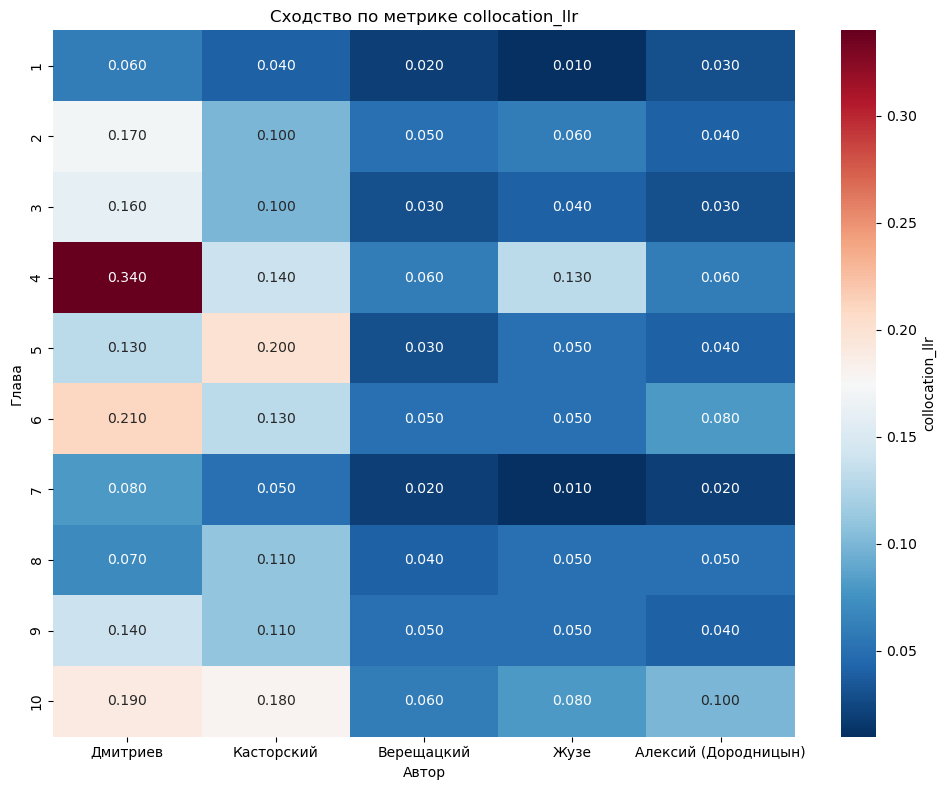

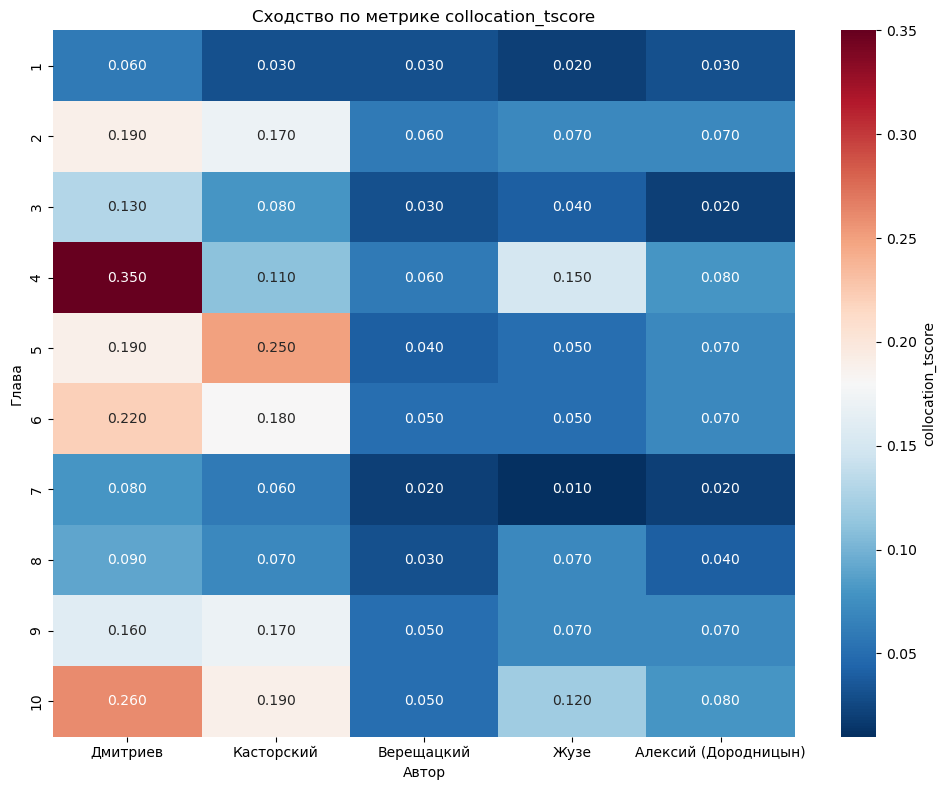

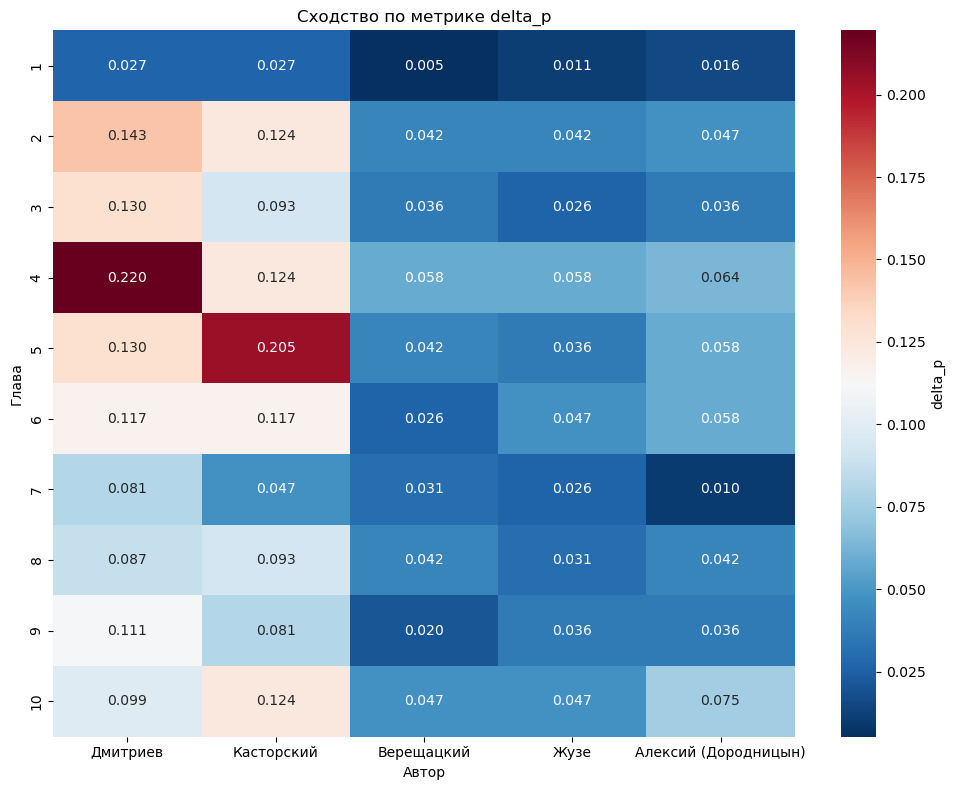

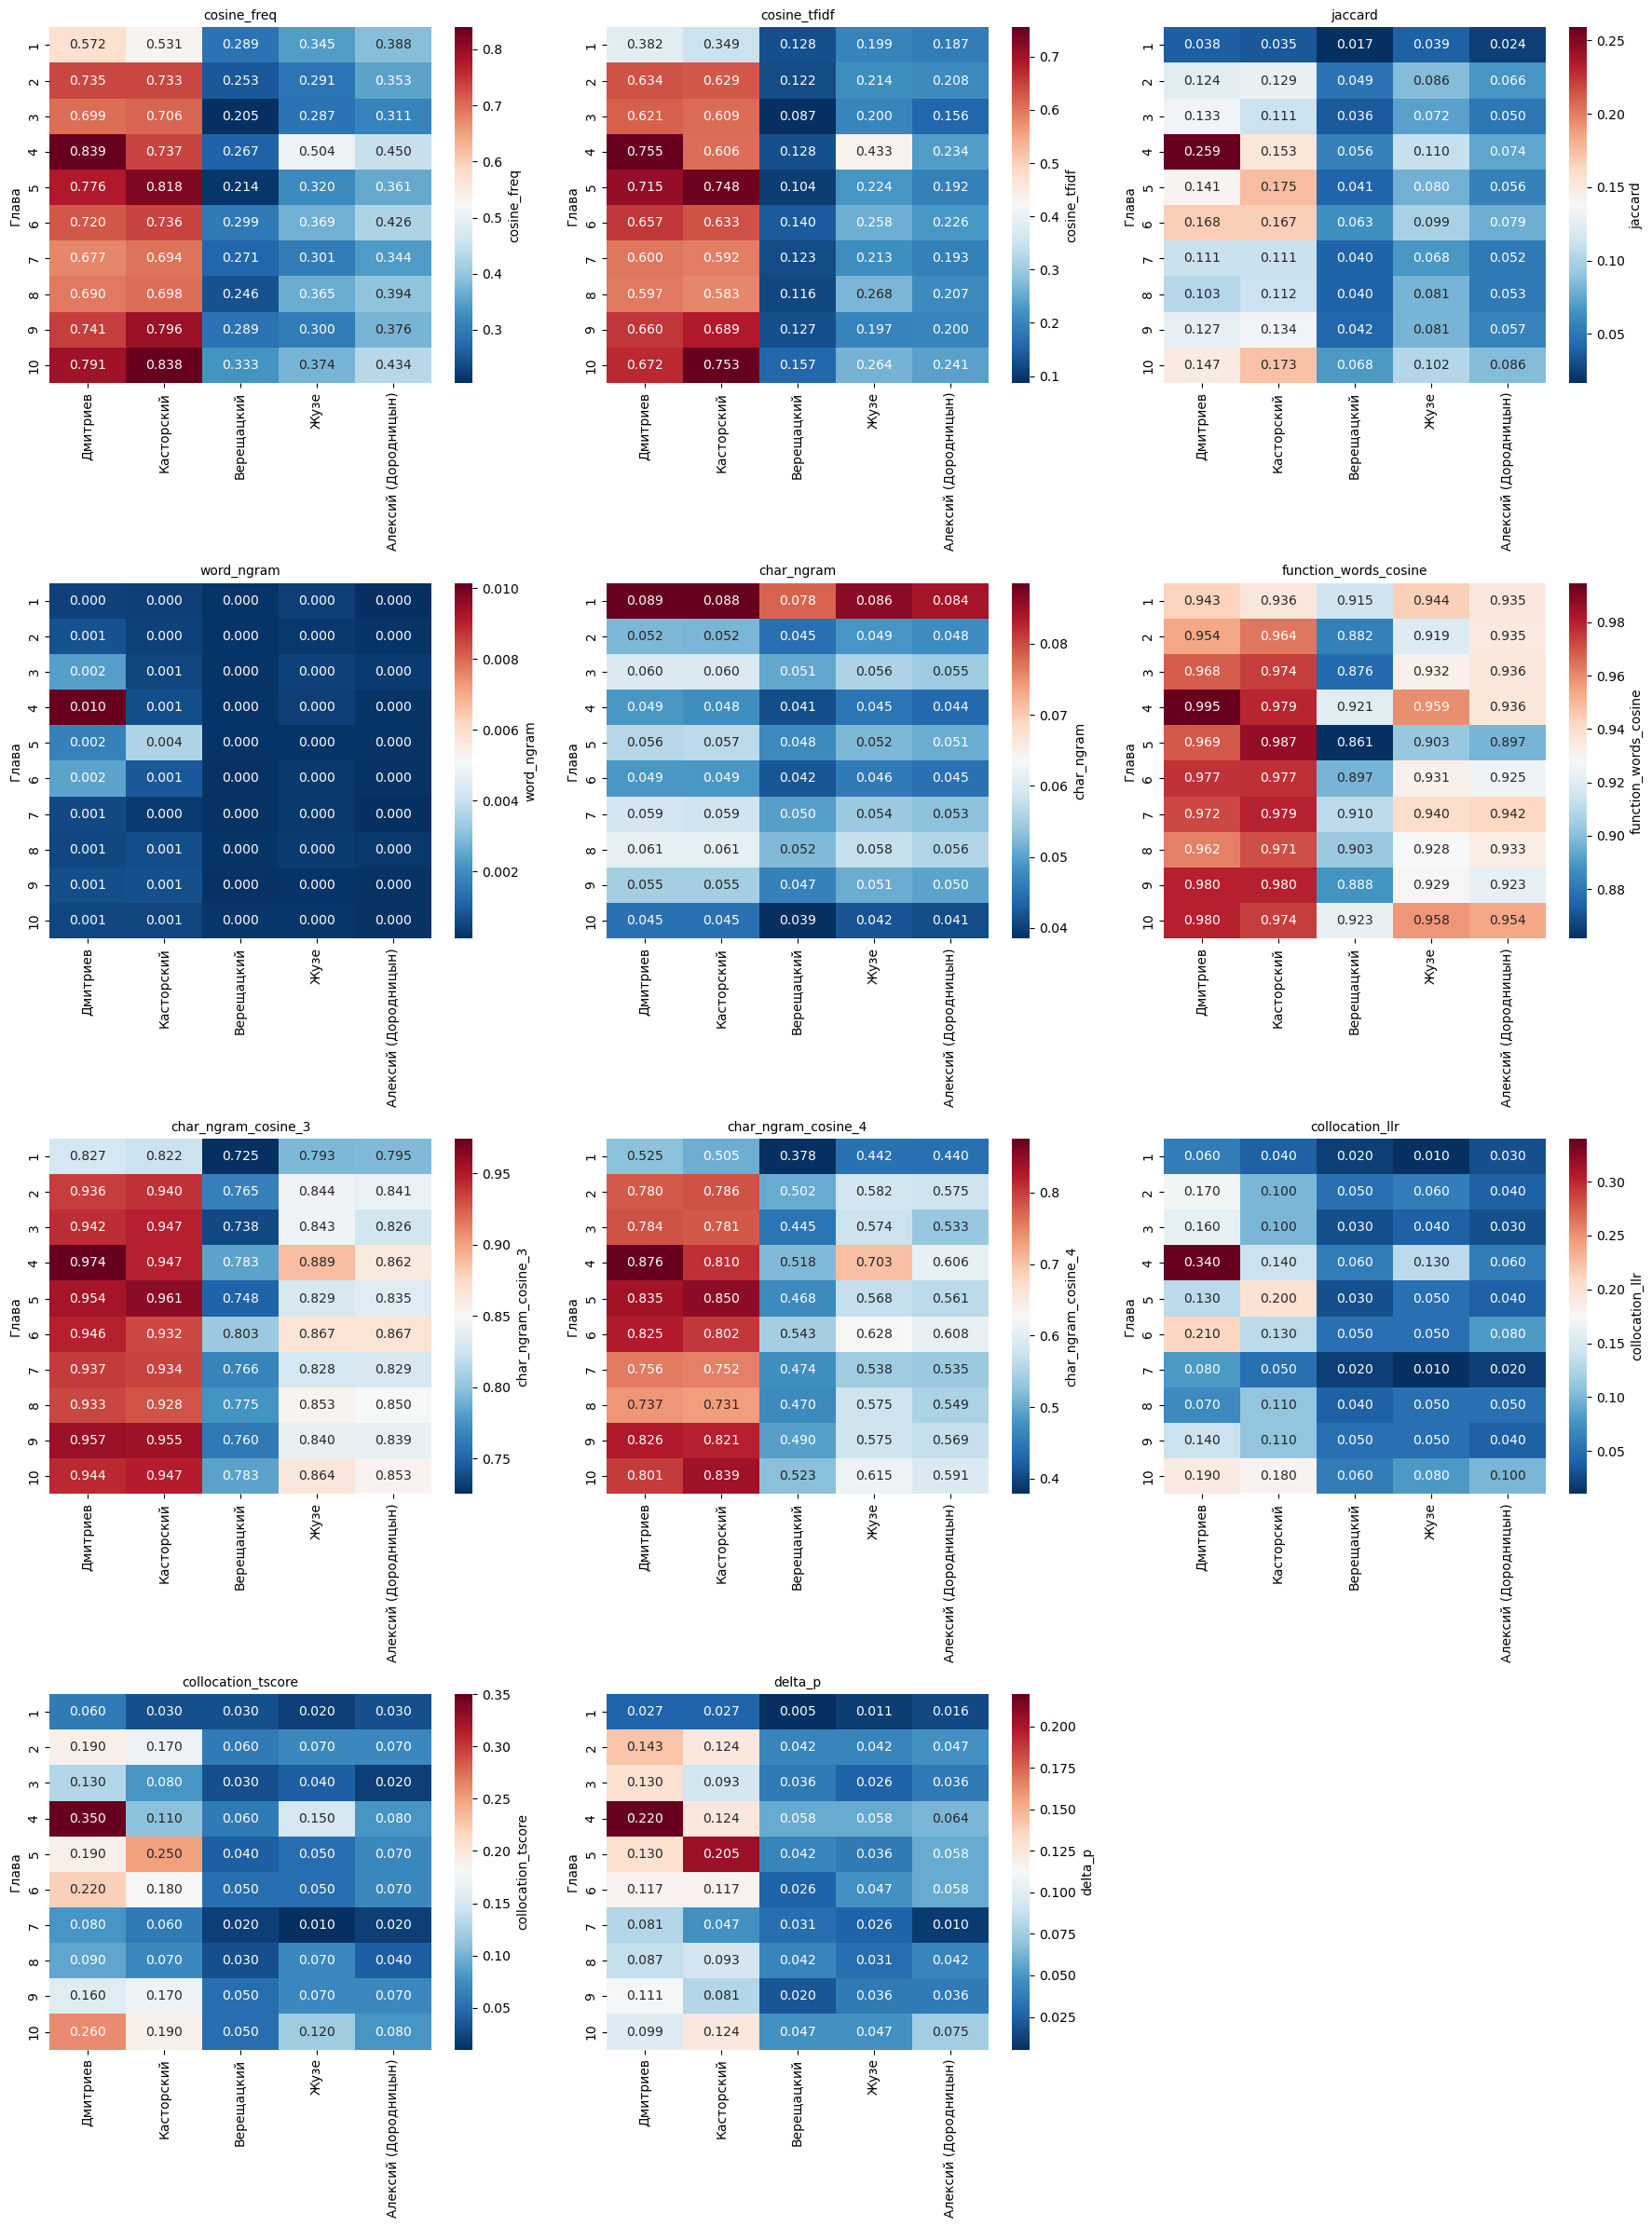

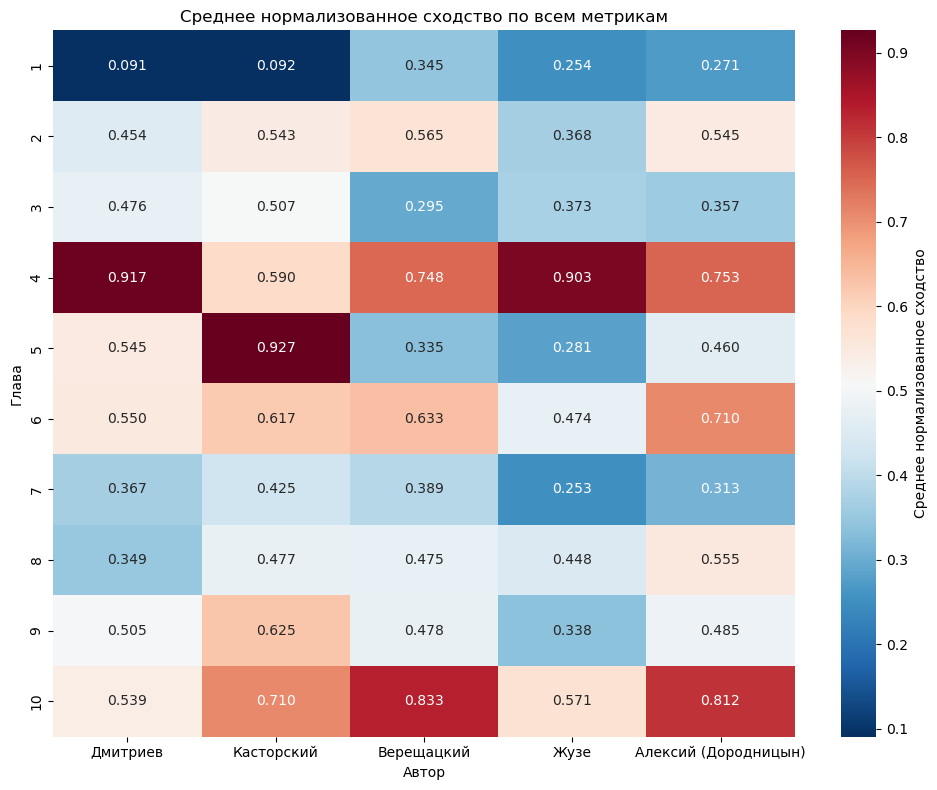

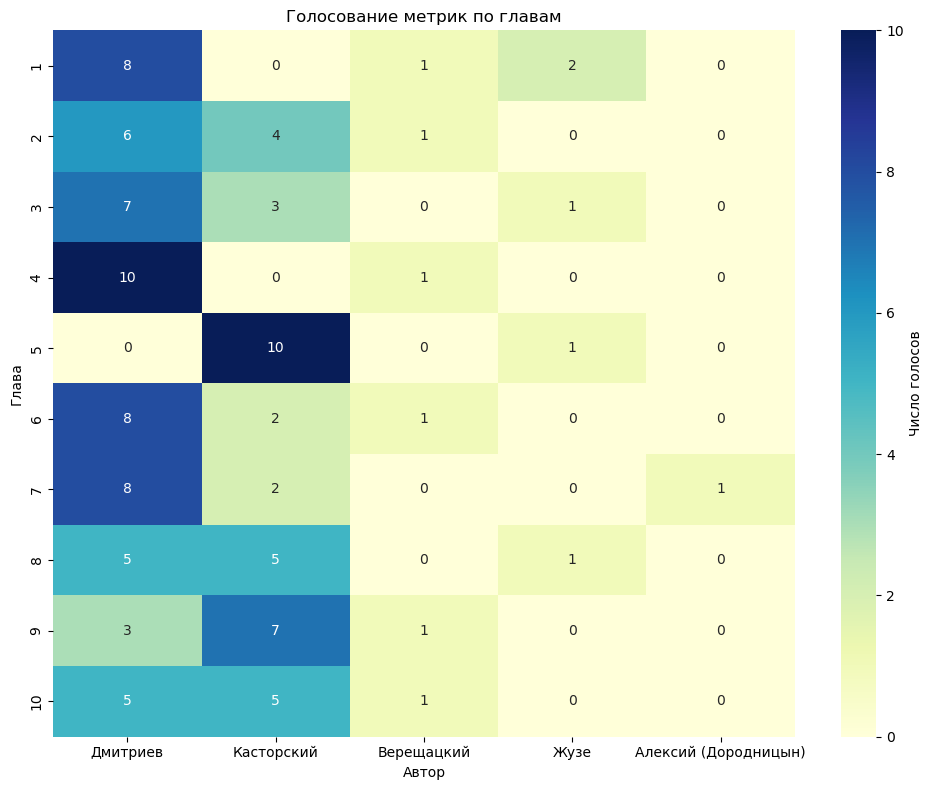


Оценка метрик на сегментах (LOO, неперекрывающиеся):
cosine_freq: accuracy = 0.981
cosine_tfidf: accuracy = 0.996
jaccard: accuracy = 0.806
word_ngram: accuracy = 1.000
char_ngram: accuracy = 0.996
function_words_cosine: accuracy = 0.823
char_ngram_cosine_3: accuracy = 0.996
char_ngram_cosine_4: accuracy = 0.998
collocation_llr: accuracy = 0.906
collocation_tscore: accuracy = 0.897
delta_p: accuracy = 0.006


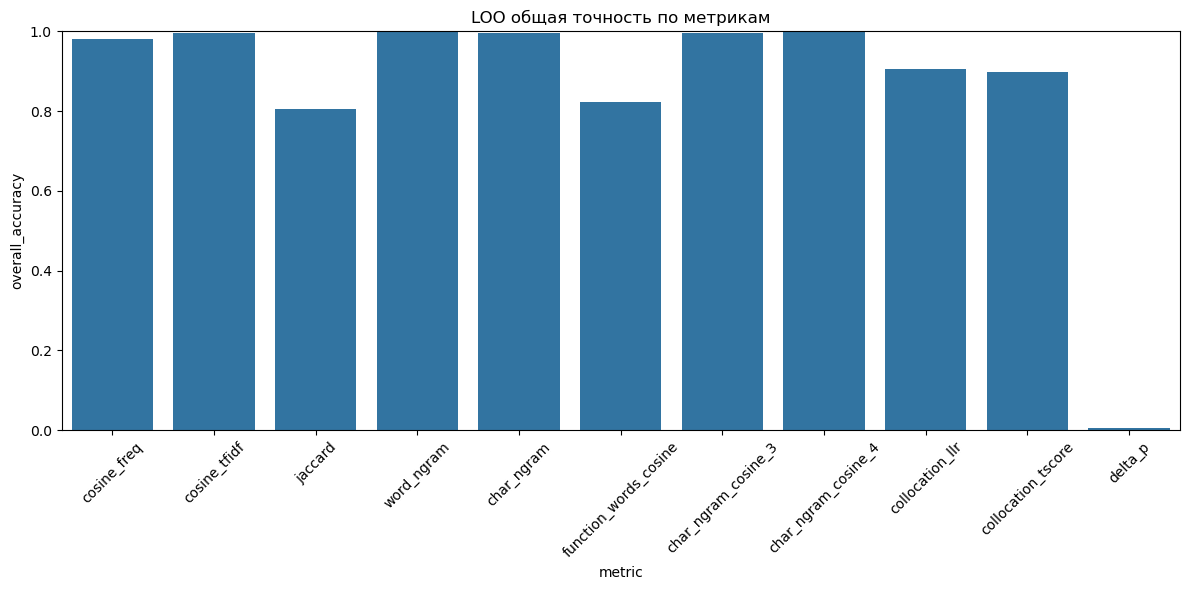

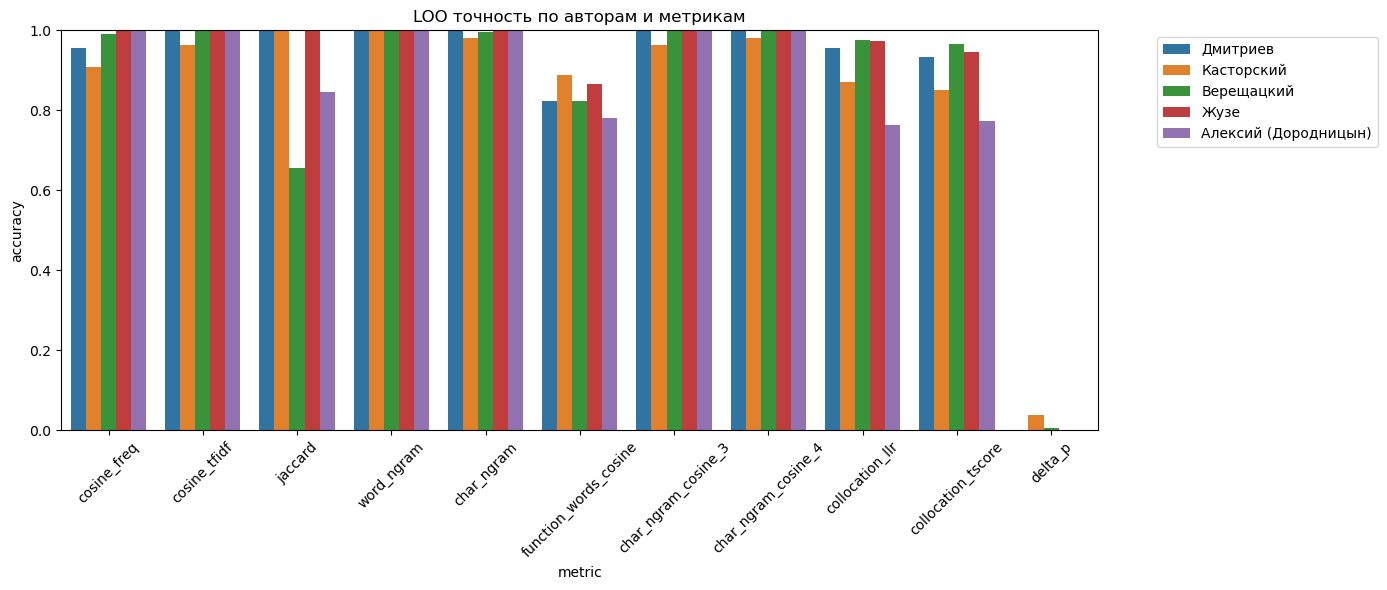


Запуск BERT ML...


Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Результаты ML (cross-val):
LR: accuracy=0.891, f1_macro=0.823
SVM: accuracy=0.893, f1_macro=0.819
KNN: accuracy=0.878, f1_macro=0.789
RF: accuracy=0.853, f1_macro=0.738
Voting: accuracy=0.897, f1_macro=0.824

Предсказания BERT по главам:
Глава 0: предсказанный автор = Дмитриев (уверенность 1.00)
Глава 1: предсказанный автор = Касторский (уверенность 0.43)
Глава 2: предсказанный автор = Дмитриев (уверенность 0.44)
Глава 3: предсказанный автор = Дмитриев (уверенность 0.67)
Глава 4: предсказанный автор = Касторский (уверенность 0.67)
Глава 5: предсказанный автор = Касторский (уверенность 0.62)
Глава 6: предсказанный автор = Касторский (уверенность 0.64)
Глава 7: предсказанный автор = Дмитриев (уверенность 0.44)
Глава 8: предсказанный автор = Касторский (уверенность 0.75)
Глава 9: предсказанный автор = Дмитриев (уверенность 0.43)

Голосование сохранено в votes_results.csv


In [ ]:
import re
import math
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import normalize, MinMaxScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import LeaveOneOut, KFold, cross_val_predict, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# ---- GPU detection ----
try:
    import torch
    DEVICE = f"cuda:{torch.cuda.current_device()}" if torch.cuda.is_available() else "cpu"
except:
    DEVICE = "cpu"
print(f"Using device: {DEVICE}")

# ---- NLTK stopwords ----
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('russian'))
STOPWORDS.update(['и', 'в', 'на', 'с', 'по', 'к', 'из', 'за', 'о', 'об', 'при', 'для', 'от', 'до', 'у', 'а', 'но', 'да',
                  'же', 'так', 'как', 'что', 'это', 'этот', 'эта', 'эти', 'тот', 'те', 'все', 'весь', 'вся', 'все'])

# ---------- 1. КОНФИГУРАЦИЯ ----------
DATA_DIR = Path('data')
CHAPTERS_DIR = DATA_DIR / 'chapters'
AUTHORS_DIR = DATA_DIR / 'authors'

AUTHOR_FILES = {
    'Дмитриев': ['Дмитриев.txt'],
    'Касторский': ['Касторский.txt'],
    'Верещацкий': ['Верещацкий_Учение блаженного Августина.txt'],
    'Жузе': ['Жузе_ Из Сирии.txt', 'Жузе_ Происхождение православных.txt', 'Жузе_ Устав.txt'],
    'Алексий (Дородницын)': ['Алексий (Дородницын)_Южно-русский необаптизм.txt']
}

# ---------- 2. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ----------
def read_text(path):
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        return f.read()

def simple_tokenize(text):
    text = re.sub(r'[^\w\s]', ' ', text.lower())
    text = re.sub(r'\d+', '', text)
    return text.split()

def preprocess(text, remove_stopwords=True):
    tokens = simple_tokenize(text)
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return tokens

def load_chapters():
    chapters = {}
    for fname in sorted(os.listdir(CHAPTERS_DIR)):
        if fname.startswith('Путевые заметки') and fname.endswith('.txt'):
            chap_num = int(re.search(r'(\d+)', fname).group(1))
            chapters[chap_num] = read_text(CHAPTERS_DIR / fname)
    return chapters

def load_authors():
    authors = {}
    for author, flist in AUTHOR_FILES.items():
        full_text = ''
        for fname in flist:
            path = AUTHORS_DIR / fname
            if path.exists():
                full_text += read_text(path) + '\n\n'
        authors[author] = full_text.strip()
    return authors

def segment_text(text, segment_size=500, step=None):
    """Неперекрывающиеся сегменты по умолчанию (step = segment_size)."""
    tokens = simple_tokenize(text)
    if not tokens:
        return []
    if step is None:
        step = segment_size
    segments = []
    for start in range(0, len(tokens), step):
        seg = tokens[start:start+segment_size]
        if len(seg) >= max(50, segment_size // 4):
            segments.append(" ".join(seg))
    if not segments and tokens:
        segments.append(" ".join(tokens))
    return segments

# ---------- 3. МЕТРИКИ (все 11) ----------
def compute_cosine_freq(chapters, authors):
    all_texts = list(chapters.values()) + list(authors.values())
    all_tokens = [preprocess(t) for t in all_texts]
    vocab = Counter()
    for tokens in all_tokens:
        vocab.update(tokens)
    top_words = [w for w, _ in vocab.most_common(500)]
    vectors = []
    for tokens in all_tokens:
        vec = [tokens.count(w) for w in top_words]
        vectors.append(vec)
    vectors = np.array(vectors)
    vectors = normalize(vectors, norm='l2')
    n_chap = len(chapters)
    res = []
    for i in range(n_chap):
        chap_vec = vectors[i]
        scores = {}
        for j, author in enumerate(authors.keys()):
            scores[author] = np.dot(chap_vec, vectors[n_chap + j])
        res.append([i+1] + [scores[a] for a in authors.keys()])
    return res, list(authors.keys())

def compute_cosine_tfidf(chapters, authors):
    all_texts = list(chapters.values()) + list(authors.values())
    vectorizer = TfidfVectorizer(tokenizer=simple_tokenize, lowercase=True,
                                 stop_words=list(STOPWORDS), max_features=1000)
    tfidf_matrix = vectorizer.fit_transform(all_texts)
    cos_sim = cosine_similarity(tfidf_matrix)
    n_chap = len(chapters)
    res = []
    for i in range(n_chap):
        scores = {}
        for j, author in enumerate(authors.keys()):
            scores[author] = cos_sim[i, n_chap + j]
        res.append([i+1] + [scores[a] for a in authors.keys()])
    return res, list(authors.keys())

def compute_jaccard(chapters, authors):
    chapter_sets = [set(preprocess(ch)) for ch in chapters.values()]
    author_sets = {a: set(preprocess(t)) for a, t in authors.items()}
    res = []
    for i, cs in enumerate(chapter_sets):
        scores = {}
        for a, aset in author_sets.items():
            inter = len(cs & aset)
            union = len(cs | aset)
            scores[a] = inter / union if union else 0.0
        res.append([i+1] + [scores[a] for a in authors.keys()])
    return res, list(authors.keys())

def compute_word_ngram(chapters, authors, n=3, window_size=500, step=50):
    def get_ngrams(tokens, n):
        return set(zip(*[tokens[i:] for i in range(n)]))
    def sliding_sim(long_text, short_text, n, window_size, step):
        tokens_long = simple_tokenize(long_text)
        tokens_short = simple_tokenize(short_text)
        if len(tokens_short) < n:
            return 0.0
        ngrams_short = get_ngrams(tokens_short, n)
        if not ngrams_short:
            return 0.0
        sims = []
        for start in range(0, max(len(tokens_long) - window_size + 1, 1), step):
            window = tokens_long[start:start+window_size]
            ngrams_win = get_ngrams(window, n)
            intersection = len(ngrams_short & ngrams_win)
            sims.append(intersection / len(ngrams_short))
        return np.mean(sims) if sims else 0.0
    res = []
    for i, ch_text in enumerate(chapters.values()):
        scores = {}
        for a, au_text in authors.items():
            scores[a] = sliding_sim(au_text, ch_text, n, window_size, step)
        res.append([i+1] + [scores[a] for a in authors.keys()])
    return res, list(authors.keys())

def compute_char_ngram(chapters, authors, n=3, window_size=500, step=50):
    def get_char_ngrams(text, n):
        text_clean = re.sub(r'\s+', '', text.lower())
        return set([text_clean[i:i+n] for i in range(len(text_clean)-n+1)])
    def sliding_sim_char(long_text, short_text, n, window_size, step):
        long_clean = re.sub(r'\s+', '', long_text.lower())
        short_clean = re.sub(r'\s+', '', short_text.lower())
        if len(short_clean) < n:
            return 0.0
        ngrams_short = set([short_clean[i:i+n] for i in range(len(short_clean)-n+1)])
        if not ngrams_short:
            return 0.0
        sims = []
        for start in range(0, max(len(long_clean) - window_size + 1, 1), step):
            window = long_clean[start:start+window_size]
            ngrams_win = set([window[i:i+n] for i in range(len(window)-n+1)])
            intersection = len(ngrams_short & ngrams_win)
            sims.append(intersection / len(ngrams_short))
        return np.mean(sims) if sims else 0.0
    res = []
    for i, ch_text in enumerate(chapters.values()):
        scores = {}
        for a, au_text in authors.items():
            scores[a] = sliding_sim_char(au_text, ch_text, n, window_size, step)
        res.append([i+1] + [scores[a] for a in authors.keys()])
    return res, list(authors.keys())

def compute_function_words_cosine(chapters, authors, top_n=300):
    fw = list(STOPWORDS)
    def fw_vector(text):
        tokens = simple_tokenize(text)
        counts = Counter([t for t in tokens if t in fw])
        vec = [counts.get(w,0) for w in fw]
        return np.array(vec, dtype=float)
    auth_vectors = {a: fw_vector(t) for a,t in authors.items()}
    for a in auth_vectors:
        norm = np.linalg.norm(auth_vectors[a])
        if norm > 0:
            auth_vectors[a] = auth_vectors[a] / norm
    res = []
    for i, ch_text in enumerate(chapters.values()):
        ch_vec = fw_vector(ch_text)
        norm = np.linalg.norm(ch_vec)
        if norm > 0:
            ch_vec = ch_vec / norm
        scores = {}
        for a, vec in auth_vectors.items():
            scores[a] = np.dot(ch_vec, vec) if norm > 0 else 0.0
        res.append([i+1] + [scores[a] for a in authors.keys()])
    return res, list(authors.keys())

def compute_char_ngram_cosine(chapters, authors, n=3):
    all_texts = list(chapters.values()) + list(authors.values())
    vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(n,n), lowercase=True)
    X = vectorizer.fit_transform(all_texts)
    cos_sim = cosine_similarity(X)
    n_chap = len(chapters)
    res = []
    for i in range(n_chap):
        scores = {}
        for j, author in enumerate(authors.keys()):
            scores[author] = cos_sim[i, n_chap + j]
        res.append([i+1] + [scores[a] for a in authors.keys()])
    return res, list(authors.keys())

def compute_collocation_llr(chapters, authors, top_k=100):
    def extract_collocations(text, top_k=100):
        tokens = simple_tokenize(text)
        if len(tokens) < 2:
            return set()
        bigrams = Counter(zip(tokens[:-1], tokens[1:]))
        unigrams = Counter(tokens)
        total = len(tokens)
        scores = {}
        for (w1,w2), freq_ab in bigrams.items():
            freq_a = unigrams.get(w1,0)
            freq_b = unigrams.get(w2,0)
            if freq_a == 0 or freq_b == 0:
                continue
            expected = (freq_a * freq_b) / total
            if expected == 0:
                continue
            ll = 2 * (freq_ab * math.log(freq_ab / expected + 1e-9))
            scores[(w1,w2)] = ll
        top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
        return set([pair for pair, _ in top])
    author_colls = {a: extract_collocations(t, top_k) for a, t in authors.items()}
    res = []
    for i, ch_text in enumerate(chapters.values()):
        ch_coll = extract_collocations(ch_text, top_k)
        scores = {}
        for a, au_coll in author_colls.items():
            inter = len(ch_coll & au_coll)
            scores[a] = inter / top_k
        res.append([i+1] + [scores[a] for a in authors.keys()])
    return res, list(authors.keys())

def compute_collocation_tscore(chapters, authors, top_k=100):
    def extract_tscore(text, top_k=100):
        tokens = simple_tokenize(text)
        if len(tokens) < 2:
            return set()
        bigrams = Counter(zip(tokens[:-1], tokens[1:]))
        unigrams = Counter(tokens)
        total = len(tokens)
        scores = {}
        for (w1,w2), freq_ab in bigrams.items():
            freq_a = unigrams.get(w1,0)
            freq_b = unigrams.get(w2,0)
            if freq_a == 0 or freq_b == 0:
                continue
            expected = (freq_a * freq_b) / total
            if expected == 0:
                continue
            tscore = (freq_ab - expected) / math.sqrt(freq_ab + 1e-9)
            scores[(w1,w2)] = tscore
        top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
        return set([pair for pair, _ in top])
    author_colls = {a: extract_tscore(t, top_k) for a, t in authors.items()}
    res = []
    for i, ch_text in enumerate(chapters.values()):
        ch_coll = extract_tscore(ch_text, top_k)
        scores = {}
        for a, au_coll in author_colls.items():
            inter = len(ch_coll & au_coll)
            scores[a] = inter / top_k
        res.append([i+1] + [scores[a] for a in authors.keys()])
    return res, list(authors.keys())

def compute_delta_p(chapters, authors, top_words=50):
    def get_dp_profile(text, top_words=50):
        tokens = simple_tokenize(text)
        if len(tokens) < 3:
            return set()
        bigrams = list(zip(tokens[:-1], tokens[1:]))
        f_w1w2 = Counter(bigrams)
        f_w1 = Counter(tokens[:-1])
        f_w2 = Counter(tokens[1:])
        total = len(bigrams)
        top_w = [w for w, _ in Counter(tokens).most_common(top_words)]
        dp = {}
        for w1 in top_w:
            for w2 in top_w:
                if w1 == w2: continue
                p_w2_given_w1 = f_w1w2.get((w1,w2),0) / (f_w1.get(w1,1) + 1e-9)
                p_w2_not_w1 = (f_w2.get(w2,0) - f_w1w2.get((w1,w2),0)) / (total - f_w1.get(w1,0) + 1e-9)
                delta = p_w2_given_w1 - p_w2_not_w1
                if delta > 0:
                    dp[(w1,w2)] = delta
        sorted_dp = sorted(dp.items(), key=lambda x: x[1], reverse=True)[:100]
        return set([pair for pair, _ in sorted_dp])
    author_dp = {a: get_dp_profile(t, top_words) for a, t in authors.items()}
    res = []
    for i, ch_text in enumerate(chapters.values()):
        ch_dp = get_dp_profile(ch_text, top_words)
        scores = {}
        for a, au_dp in author_dp.items():
            inter = len(ch_dp & au_dp)
            union = len(ch_dp | au_dp)
            scores[a] = inter / union if union else 0.0
        res.append([i+1] + [scores[a] for a in authors.keys()])
    return res, list(authors.keys())

# ---------- 4. ГОЛОСОВАНИЕ ----------
def voting_aggregate(metric_results, authors):
    df_votes = pd.DataFrame(0, index=range(1, 11), columns=authors)
    for metric_name, (res, auth_list) in metric_results.items():
        for row in res:
            chap = int(row[0])
            scores = row[1:]
            if 'delta' in metric_name.lower():
                best_idx = np.argmin(scores)
            else:
                best_idx = np.argmax(scores)
            winner = auth_list[best_idx]
            df_votes.loc[chap, winner] += 1
    df_votes['winner'] = df_votes[authors].idxmax(axis=1)
    df_votes['max_votes'] = df_votes[authors].max(axis=1)
    return df_votes

# ---------- 5. ВИЗУАЛИЗАЦИЯ ----------
def plot_metric_heatmaps(metric_results, authors):
    for metric_name, (res, auth_list) in metric_results.items():
        df = pd.DataFrame(res, columns=['chapter'] + auth_list)
        df.set_index('chapter', inplace=True)
        plt.figure(figsize=(10, 8))
        sns.heatmap(df, annot=True, fmt='.3f', cmap='RdBu_r', cbar_kws={'label': metric_name})
        plt.title(f'Сходство по метрике {metric_name}')
        plt.ylabel('Глава')
        plt.xlabel('Автор')
        plt.tight_layout()
        plt.show()

def plot_combined_heatmap(metric_results, authors):
    all_dfs = []
    for metric_name, (res, auth_list) in metric_results.items():
        df = pd.DataFrame(res, columns=['chapter'] + auth_list)
        df.set_index('chapter', inplace=True)
        all_dfs.append(df)
    norm_dfs = []
    for df in all_dfs:
        scaler = MinMaxScaler()
        norm_df = pd.DataFrame(scaler.fit_transform(df), index=df.index, columns=df.columns)
        norm_dfs.append(norm_df)
    combined = pd.concat(norm_dfs).groupby(level=0).mean()
    plt.figure(figsize=(10, 8))
    sns.heatmap(combined, annot=True, fmt='.3f', cmap='RdBu_r', cbar_kws={'label': 'Среднее нормализованное сходство'})
    plt.title('Среднее нормализованное сходство по всем метрикам')
    plt.ylabel('Глава')
    plt.xlabel('Автор')
    plt.tight_layout()
    plt.show()

def plot_votes_heatmap(df_votes, authors):
    data = df_votes[authors]
    plt.figure(figsize=(10, 8))
    sns.heatmap(data, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'Число голосов'})
    plt.title('Голосование метрик по главам')
    plt.ylabel('Глава')
    plt.xlabel('Автор')
    plt.tight_layout()
    plt.show()

def plot_loo_accuracy(metric_results, authors_dict, authors_list, metric_functions):
    """authors_dict - словарь {имя: текст}, authors_list - список имён для подписей"""
    loo_results = []
    for name, (res, auth_list) in metric_results.items():
        func = None
        for m_name, m_func in metric_functions:
            if m_name == name:
                func = m_func
                break
        if func is not None:
            overall, correct, total = evaluate_metric_on_segments(func, authors_dict, segment_size=500)
            loo_results.append({
                'metric': name,
                'overall_accuracy': overall,
                **{f'acc_{a}': correct[a]/total[a] if total[a] > 0 else 0 for a in authors_list}
            })
    df_loo = pd.DataFrame(loo_results)
    # Общая точность
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_loo, x='metric', y='overall_accuracy')
    plt.ylim(0, 1)
    plt.title('LOO общая точность по метрикам')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    # Точность по авторам
    df_melt = df_loo.melt(id_vars=['metric'], value_vars=[f'acc_{a}' for a in authors_list],
                          var_name='author', value_name='accuracy')
    df_melt['author'] = df_melt['author'].str.replace('acc_', '')
    plt.figure(figsize=(14, 6))
    sns.barplot(data=df_melt, x='metric', y='accuracy', hue='author')
    plt.ylim(0, 1)
    plt.title('LOO точность по авторам и метрикам')
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()
    return df_loo

# ---------- 6. КРОСС-ВАЛИДАЦИЯ (LOO) ----------
def evaluate_metric_on_segments(metric_func, authors, segment_size=500):
    seg_dict = {}
    for author, text in authors.items():
        segs = segment_text(text, segment_size)   # неперекрывающиеся
        if segs:
            seg_dict[author] = segs
        else:
            seg_dict[author] = [text]
    correct_per_author = {a: 0 for a in authors}
    total_per_author = {a: 0 for a in authors}
    for author, segs in seg_dict.items():
        for seg in segs:
            temp_chapters = {1: seg}
            res, auth_list = metric_func(temp_chapters, authors)
            scores = res[0][1:]
            if 'delta' in metric_func.__name__.lower():
                pred_idx = np.argmin(scores)
            else:
                pred_idx = np.argmax(scores)
            pred_author = auth_list[pred_idx]
            total_per_author[author] += 1
            if pred_author == author:
                correct_per_author[author] += 1
    overall = sum(correct_per_author.values()) / sum(total_per_author.values()) if sum(total_per_author.values()) > 0 else 0.0
    return overall, correct_per_author, total_per_author

# ---------- 7. МАШИННОЕ ОБУЧЕНИЕ С BERT ----------
def bert_ml_pipeline(authors, chapters, segment_size=500):
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device=DEVICE)

    # Обучающая выборка – неперекрывающиеся сегменты
    X_train = []
    y_train = []
    for author, text in authors.items():
        segs = segment_text(text, segment_size)
        X_train.extend(segs)
        y_train.extend([author]*len(segs))
    if not X_train:
        for author, text in authors.items():
            X_train.append(text)
            y_train.append(author)

    X_emb = model.encode(X_train, convert_to_numpy=True, show_progress_bar=True)
    X_emb = normalize(X_emb)

    clfs = {
        'LR': LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42),
        'SVM': LinearSVC(class_weight='balanced', random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5, metric='cosine'),
        'RF': RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced_subsample'),
        'Voting': VotingClassifier(estimators=[
            ('lr', LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)),
            ('svc', LinearSVC(class_weight='balanced', random_state=42)),
            ('knn', KNeighborsClassifier(n_neighbors=5, metric='cosine'))
        ], voting='hard')
    }
    results = {}
    for name, clf in clfs.items():
        preds = cross_val_predict(clf, X_emb, y_train, cv=5)
        acc = accuracy_score(y_train, preds)
        f1 = f1_score(y_train, preds, average='macro')
        results[name] = {'accuracy': acc, 'f1_macro': f1}

    final_clf = clfs['Voting']
    final_clf.fit(X_emb, y_train)

    # Предсказание глав – неперекрывающиеся окна
    chapter_predictions = {}
    for chap_num, ch_text in chapters.items():
        windows = segment_text(ch_text, segment_size)
        if not windows:
            windows = [ch_text]
        win_emb = model.encode(windows, convert_to_numpy=True, show_progress_bar=False)
        win_emb = normalize(win_emb)
        preds = final_clf.predict(win_emb)
        vote_counts = Counter(preds)
        winner = vote_counts.most_common(1)[0][0]
        chapter_predictions[chap_num] = {
            'windows': windows,
            'preds': preds,
            'winner': winner,
            'conf': vote_counts[winner]/len(preds)
        }
    return results, chapter_predictions

# ---------- 8. ОСНОВНОЙ ПОТОК ----------
def main():
    chapters = load_chapters()
    authors = load_authors()
    print(f"Загружено глав: {len(chapters)}, авторов: {len(authors)}")

    metric_functions = [
        ('cosine_freq', compute_cosine_freq),
        ('cosine_tfidf', compute_cosine_tfidf),
        ('jaccard', compute_jaccard),
        ('word_ngram', compute_word_ngram),
        ('char_ngram', compute_char_ngram),
        ('function_words_cosine', compute_function_words_cosine),
        ('char_ngram_cosine_3', lambda ch, auth: compute_char_ngram_cosine(ch, auth, n=3)),
        ('char_ngram_cosine_4', lambda ch, auth: compute_char_ngram_cosine(ch, auth, n=4)),
        ('collocation_llr', compute_collocation_llr),
        ('collocation_tscore', compute_collocation_tscore),
        ('delta_p', compute_delta_p)
    ]

    metric_results = {}
    authors_list = list(authors.keys())
    for name, func in metric_functions:
        print(f"Вычисление {name}...")
        res, auth_list = func(chapters, authors)
        metric_results[name] = (res, auth_list)

    # TTR (для информации)
    def ttr_metrics(text):
        tokens = simple_tokenize(text)
        if not tokens: return {'TTR':0, 'Entropy':0, 'YuleK':0}
        types = set(tokens)
        ttr = len(types) / len(tokens)
        freqs = Counter(tokens)
        probs = [f/len(tokens) for f in freqs.values()]
        entropy = -sum(p * math.log2(p) for p in probs)
        freq_of_freq = Counter(freqs.values())
        n = len(tokens)
        yule = (sum(f**2 * count for f,count in freq_of_freq.items()) - n) / (n*n)
        return {'TTR':ttr, 'Entropy':entropy, 'YuleK':yule}
    chap_ttr = {i: ttr_metrics(t) for i, t in enumerate(chapters.values(), start=1)}
    print("TTR глав:", chap_ttr)

    # Голосование
    df_votes = voting_aggregate(metric_results, authors_list)
    print("\nРезультаты голосования:")
    print(df_votes)

    # Визуализация
    plot_metric_heatmaps(metric_results, authors_list)        # отдельные большие
    plot_all_metric_heatmaps_grid(metric_results, authors_list, ncols=3, figsize=(18, 24))  # сетка всех метрик
    plot_combined_heatmap(metric_results, authors_list)        # усреднённый
    plot_votes_heatmap(df_votes, authors_list)                # голосование

    # LOO
    print("\nОценка метрик на сегментах (LOO, неперекрывающиеся):")
    for name, (res, auth_list) in metric_results.items():
        func = None
        for m_name, m_func in metric_functions:
            if m_name == name:
                func = m_func
                break
        if func is not None:
            acc, _, _ = evaluate_metric_on_segments(func, authors, segment_size=500)
            print(f"{name}: accuracy = {acc:.3f}")
    df_loo = plot_loo_accuracy(metric_results, authors, authors_list, metric_functions)

    # BERT ML
    print("\nЗапуск BERT ML...")
    bert_results, bert_chapter_preds = bert_ml_pipeline(authors, chapters, segment_size=500)
    print("Результаты ML (cross-val):")
    for model, scores in bert_results.items():
        print(f"{model}: accuracy={scores['accuracy']:.3f}, f1_macro={scores['f1_macro']:.3f}")
    print("\nПредсказания BERT по главам:")
    for chap, info in bert_chapter_preds.items():
        print(f"Глава {chap}: предсказанный автор = {info['winner']} (уверенность {info['conf']:.2f})")

    # Сохраняем голосование
    df_votes.to_csv('votes_results.csv', encoding='utf-8-sig')
    print("\nГолосование сохранено в votes_results.csv")

if __name__ == '__main__':
    main()